# Model 1A, Experiment 01: Raw Decision-Tree Baseline

This notebook rebuilds the first-pass grid-searched decision tree for flights departing JFK. The target, `DepDel15`, equals 1 when departure delay is at least 15 minutes and 0 otherwise.

Experiment 01 uses the same 20 **raw, pre-pushback** schedule, flight-identity, planned-demand, and weather predictors as the raw logistic-regression baseline. The revised methodology is shared across the Model 1A experiments:

- complete calendar days are kept together;
- grid search uses five expanding-window day folds within 2019;
- the selected pipeline is refitted on all 2019 flights and evaluated once on 2023;
- missing-value treatment and encoding are fitted inside every training fold;
- average precision selects tree complexity and class weighting;
- the operating threshold is selected from 2019 out-of-fold probabilities only;
- 2023 labels are used only for external development/validation metrics;
- the 2024 dataset is not loaded.

Appendix C engineered predictors are reserved for Experiment 02, making the two tree notebooks a controlled raw-versus-engineered comparison.


In [1]:
# Parameters
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"

RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4


In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


## Load and validate the shared 2019 and 2023 departure feature data

The path lookup supports running from either the project root or the `models` directory. Although the source contains Appendix C engineered columns, the explicit Experiment 01 allowlist below admits only raw fields.

In [3]:
def find_project_root(start: Path, airport: str, years) -> Path:
    """Return the nearest parent containing every requested feature file."""
    relative_paths = [
        Path("data/features") / f"{airport}_{year}_departures.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).exists() for path in relative_paths):
            return candidate
    raise FileNotFoundError(f"Could not locate all required files: {relative_paths}")


PROJECT_ROOT = find_project_root(
    Path.cwd().resolve(),
    AIRPORT,
    [TRAIN_YEAR, VALIDATION_YEAR],
)
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_departures.csv"
VALIDATION_DATA_PATH = (
    PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_departures.csv"
)

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)

print(f"Training source: {TRAIN_DATA_PATH}")
print(f"Training rows: {len(train_df):,}; columns: {train_df.shape[1]:,}")
print(f"Validation source: {VALIDATION_DATA_PATH}")
print(f"Validation rows: {len(validation_df):,}; columns: {validation_df.shape[1]:,}")


Training source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2019_departures.csv
Training rows: 107,430; columns: 112
Validation source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2023_departures.csv
Validation rows: 109,983; columns: 112


In [4]:
def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    """Validate one source population and return its audit summary."""
    required_audit_columns = {"FlightDate", "Origin", TARGET}
    missing_audit_columns = sorted(required_audit_columns - set(frame.columns))
    assert not missing_audit_columns, f"{partition} missing audit columns: {missing_audit_columns}"

    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="coerce")
    assert frame["FlightDate"].notna().all(), f"{partition} has invalid FlightDate values"
    assert frame["FlightDate"].dt.year.eq(year).all(), f"{partition} has rows outside {year}"
    assert frame["Origin"].eq(AIRPORT).all(), f"{partition} Origin must equal {AIRPORT}"
    assert frame[TARGET].notna().all(), f"{partition} {TARGET} contains missing values"
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0}), (
        f"{partition} has unexpected {TARGET} values"
    )

    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame(
    [
        validate_source_frame(train_df, TRAIN_YEAR, "training"),
        validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
    ]
).set_index("partition")
source_summary


,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107430,20168,0.1877
external validation,2023,2023-01-01,2023-12-31,365,109983,25995,0.2364


## Raw prediction-time feature manifest

The allowlist repeats the first-pass feature groups:

1. **Calendar and schedule:** month, weekday, scheduled departure/arrival HHMM, scheduled elapsed time, and distance.
2. **Flight identity:** reporting airline and destination.
3. **Planned airport demand:** scheduled arrivals and departures in the previous, current, and next clock hours.
4. **Causally available weather:** the most recent raw temperature, precipitation, humidity, visibility, and wind-speed measurements available by scheduled departure.

This experiment deliberately retains raw HHMM fields so that Experiment 02 can measure the incremental value of cyclical and other engineered representations. Actual departure, taxi, takeoff, arrival outcomes, audit timestamps, and engineered columns are excluded.

In [5]:
# Month and weekday are categorical because their numeric spacing is not a linear effect.
categorical_features = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Dest",
]

numeric_features = [
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES",
    "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES",
    "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES",
    "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature",
    "HourlyDryBulbTemperature",
    "HourlyPrecipitation",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
    "HourlyWindSpeed",
]

feature_columns = categorical_features + numeric_features
required_columns = ["FlightDate", "Origin", TARGET, *feature_columns]
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing_columns = sorted(set(required_columns) - set(frame.columns))
    assert not missing_columns, f"{partition} missing required columns: {missing_columns}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelay",
    "DepDelayMinutes",
    "DepartureDelayGroups",
    "TaxiOut",
    "WheelsOff",
    "ArrDel15",
    "ArrivalDelayGroups",
    "Tail_Number",
}
leaking_columns = sorted(forbidden_predictors.intersection(feature_columns))
assert not leaking_columns, f"Prediction-time-invalid features selected: {leaking_columns}"

engineered_prefixes = (
    "SCHED_",
    "LOG_",
    "ASPM_THREE_",
    "ACTUAL_",
)
unexpected_engineered = [
    column for column in feature_columns
    if column.startswith(engineered_prefixes)
]
assert not unexpected_engineered, f"Experiment 01 must remain raw: {unexpected_engineered}"

print(f"Selected {len(feature_columns)} raw source predictors")
print(f"  categorical: {len(categorical_features)}")
print(f"  numeric: {len(numeric_features)}")


Selected 20 raw source predictors
  categorical: 4
  numeric: 16


## Missingness and temporal partitions

All 2019 rows form the training dataset. Its calendar days are divided into six consecutive blocks; five expanding-window folds train on all earlier blocks and validate on the next block. After selection, grid search refits the winning pipeline on all 2019 rows. The separately loaded 2023 rows are evaluated only after that refit.

No row is dropped for a missing predictor. Categorical mode imputation and numeric median imputation are learned separately inside every training fold. Numeric missingness indicators are added only when a training fold contains a missing value.

In [6]:
def prepare_model_frame(source_frame: pd.DataFrame) -> pd.DataFrame:
    """Select columns, sort chronologically, and normalize input dtypes."""
    model_frame = source_frame[required_columns].copy()
    model_frame = model_frame.sort_values(
        ["FlightDate", "CRSDepTime"],
        kind="stable",
    ).reset_index(drop=True)
    model_frame[TARGET] = model_frame[TARGET].astype(int)

    for column in categorical_features:
        model_frame[column] = model_frame[column].astype(object)
    for column in numeric_features:
        model_frame[column] = pd.to_numeric(model_frame[column], errors="coerce")

    return model_frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)

missing_summary = pd.DataFrame(
    {
        "training_missing": train_model_df[feature_columns].isna().sum(),
        "validation_missing": validation_model_df[feature_columns].isna().sum(),
    }
)
display(missing_summary[missing_summary.sum(axis=1).gt(0)])

X_train = train_model_df[feature_columns].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)

X_validation = validation_model_df[feature_columns].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()


,training_missing,validation_missing
ASPM_NEXT_SCHEDULED_DEPARTURES,1,0
ASPM_NEXT_SCHEDULED_ARRIVALS,1,0
HourlyDewPointTemperature,46,0
HourlyPrecipitation,22,21
HourlyVisibility,0,28


In [7]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    """Create expanding train/validation indices without splitting calendar days."""
    normalized_dates = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized_dates)))

    if len(unique_days) < n_splits + 1:
        raise ValueError("Not enough unique days for the requested temporal folds")

    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits = []
    rows = []

    for fold_number in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold_number])
        validation_days = day_blocks[fold_number]
        train_indices = np.flatnonzero(np.isin(normalized_dates, train_days))
        validation_indices = np.flatnonzero(np.isin(normalized_dates, validation_days))

        assert train_indices.size and validation_indices.size
        assert train_days.max() < validation_days.min()
        splits.append((train_indices, validation_indices))
        rows.append(
            {
                "fold": fold_number,
                "train_start": pd.Timestamp(train_days.min()).date(),
                "train_end": pd.Timestamp(train_days.max()).date(),
                "validation_start": pd.Timestamp(validation_days.min()).date(),
                "validation_end": pd.Timestamp(validation_days.max()).date(),
                "train_rows": len(train_indices),
                "validation_rows": len(validation_indices),
                "train_delay_rate": targets.iloc[train_indices].mean(),
                "validation_delay_rate": targets.iloc[validation_indices].mean(),
            }
        )

    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates,
    y_train,
    N_TIME_SPLITS,
)

partition_summary = pd.DataFrame(
    {
        "start": [training_dates.min().date(), validation_dates.min().date()],
        "end": [training_dates.max().date(), validation_dates.max().date()],
        "days": [
            training_dates.dt.normalize().nunique(),
            validation_dates.dt.normalize().nunique(),
        ],
        "rows": [len(y_train), len(y_validation)],
        "delayed_flights": [y_train.sum(), y_validation.sum()],
        "delay_rate": [y_train.mean(), y_validation.mean()],
    },
    index=["2019 training", "2023 external validation"],
)

display(partition_summary)
fold_summary


,start,end,days,rows,delayed_flights,delay_rate
2019 training,2019-01-01,2019-12-31,365,107430,20168,0.1877
2023 external validation,2023-01-01,2023-12-31,365,109983,25995,0.2364


,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,train_delay_rate,validation_delay_rate
fold,,,,,,,,
1,2019-01-01,2019-03-02,2019-03-03,2019-05-02,17737,18776,0.1892,0.1674
2,2019-01-01,2019-05-02,2019-05-03,2019-07-02,36513,18150,0.1780,0.2072
3,2019-01-01,2019-07-02,2019-07-03,2019-09-01,54663,17758,0.1877,0.2577
4,2019-01-01,2019-09-01,2019-09-02,2019-11-01,72421,17686,0.2048,0.1384
5,2019-01-01,2019-11-01,2019-11-02,2019-12-31,90107,17323,0.1918,0.1666


## Preprocessing and decision-tree search

Categorical mode imputation, one-hot encoding, numeric median imputation, and missingness indicators are part of the pipeline. Every learned transformation is therefore fitted only on the training portion of each temporal fold.

The grid repeats the first-pass tree search while replacing shuffled cross-validation with expanding-day folds. It compares:

- Gini and entropy split criteria;
- maximum depths of 5, 8, 10, and 15;
- minimum split sizes of 250 and 500;
- minimum leaf sizes of 100, 200, and 500;
- unweighted and balanced-class trees.

These limits deliberately prevent a single tree from memorizing individual flights while allowing enough depth to discover schedule, traffic, weather, airline, and destination interactions.


In [8]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_pipeline, categorical_features),
        ("numeric", numeric_pipeline, numeric_features),
    ],
    remainder="drop",
)

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(random_state=RANDOM_STATE),
        ),
    ]
)

parameter_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [5, 8, 10, 15],
    "classifier__min_samples_split": [250, 500],
    "classifier__min_samples_leaf": [100, 200, 500],
    "classifier__class_weight": [None, "balanced"],
}

scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "mcc": make_scorer(matthews_corrcoef),
    "neg_brier": "neg_brier_score",
}

grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=parameter_grid,
    scoring=scoring,
    refit="average_precision",
    cv=temporal_splits,
    n_jobs=N_JOBS,
    pre_dispatch=N_JOBS,
    verbose=1,
    return_train_score=False,
    error_score="raise",
)

parameter_count = len(list(ParameterGrid(parameter_grid)))
print(f"Hyperparameter combinations: {parameter_count:,}")
print(f"Temporal cross-validation fits: {parameter_count * len(temporal_splits):,}")


Hyperparameter combinations: 96
Temporal cross-validation fits: 480


In [9]:
search_start = perf_counter()
grid_search.fit(X_train, y_train)
search_seconds = perf_counter() - search_start

best_decision_tree_pipeline = grid_search.best_estimator_
fitted_tree = best_decision_tree_pipeline.named_steps["classifier"]

print(f"Grid search and refit completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation average precision: {grid_search.best_score_:.4f}")
print(f"Refitted tree depth: {fitted_tree.get_depth()}")
print(f"Refitted terminal leaves: {fitted_tree.get_n_leaves():,}")
print("Best parameters:")
display(pd.Series(grid_search.best_params_, name="value").to_frame())


Fitting 5 folds for each of 96 candidates, totalling 480 fits


/Users/johnkyte/Projects/berkeley_ml_and_ai/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Grid search and refit completed in 59.7 seconds
Best mean temporal-validation average precision: 0.2961
Refitted tree depth: 15
Refitted terminal leaves: 157
Best parameters:


,value
classifier__class_weight,balanced
classifier__criterion,entropy
classifier__max_depth,15
classifier__min_samples_leaf,500
classifier__min_samples_split,250


In [10]:
cv_results = pd.DataFrame(grid_search.cv_results_)

result_columns = [
    "rank_test_average_precision",
    "mean_test_average_precision",
    "std_test_average_precision",
    "mean_test_roc_auc",
    "mean_test_balanced_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_mcc",
    "mean_test_neg_brier",
    "param_classifier__criterion",
    "param_classifier__max_depth",
    "param_classifier__min_samples_split",
    "param_classifier__min_samples_leaf",
    "param_classifier__class_weight",
]

display(
    cv_results.sort_values("rank_test_average_precision")[result_columns].head(12)
)

complexity_comparison = (
    cv_results.groupby(
        ["param_classifier__max_depth", "param_classifier__class_weight"],
        dropna=False,
    )
    .agg(
        best_mean_average_precision=("mean_test_average_precision", "max"),
        best_mean_roc_auc=("mean_test_roc_auc", "max"),
        best_mean_neg_brier=("mean_test_neg_brier", "max"),
        candidates=("mean_test_average_precision", "size"),
    )
    .sort_values("best_mean_average_precision", ascending=False)
)
complexity_comparison.head(12)


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_balanced_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_mcc,mean_test_neg_brier,param_classifier__criterion,param_classifier__max_depth,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__class_weight
95,1,0.2961,0.0600,0.6605,0.6207,0.2744,0.6172,0.3772,0.1909,-0.2299,entropy,15,500,500,balanced
94,1,0.2961,0.0600,0.6605,0.6207,0.2744,0.6172,0.3772,0.1909,-0.2299,entropy,15,250,500,balanced
71,3,0.2959,0.0607,0.6604,0.6200,0.2725,0.6233,0.3766,0.1895,-0.2304,gini,15,500,500,balanced
70,3,0.2959,0.0607,0.6604,0.6200,0.2725,0.6233,0.3766,0.1895,-0.2304,gini,15,250,500,balanced
46,5,0.2945,0.0576,0.6599,0.5133,0.1735,0.0406,0.0629,0.0500,-0.1451,entropy,15,250,500,NaN
47,5,0.2945,0.0576,0.6599,0.5133,0.1735,0.0406,0.0629,0.0500,-0.1451,entropy,15,500,500,NaN
88,7,0.2940,0.0613,0.6597,0.6201,0.2724,0.6254,0.3764,0.1896,-0.2299,entropy,10,250,500,balanced
89,7,0.2940,0.0613,0.6597,0.6201,0.2724,0.6254,0.3764,0.1896,-0.2299,entropy,10,500,500,balanced
41,9,0.2940,0.0581,0.6600,0.5133,0.1735,0.0406,0.0629,0.0500,-0.1451,entropy,10,500,500,NaN
40,9,0.2940,0.0581,0.6600,0.5133,0.1735,0.0406,0.0629,0.0500,-0.1451,entropy,10,250,500,NaN


best_mean_average_precision  \
param_classifier__max_depth param_classifier__class_weight                                
15                          balanced                                             0.2961   
                            NaN                                                  0.2945   
10                          balanced                                             0.2940   
                            NaN                                                  0.2940   
8                           NaN                                                  0.2934   
                            balanced                                             0.2929   
5                           NaN                                                  0.2839   
                            balanced                                             0.2838   

                                                            best_mean_roc_auc  \
param_classifier__max_depth param_classifier__class_weight                      
15                          balanced                                   0.6605   
                            NaN                                        0.6599   
10                          balanced                                   0.6597   
                            NaN                                        0.6600   
8                           NaN                                        0.6614   
                            balanced                                   0.6613   
5                           NaN                                        0.6576   
                            balanced                                   0.6562   

                                                            best_mean_neg_brier  \
param_classifier__max_depth param_classifier__class_weight                        
15                          balanced                                    -0.2299   
                            NaN                                         -0.1451   
10                          balanced                                    -0.2299   
                            NaN                                         -0.1451   
8                           NaN                                         -0.1451   
                            balanced                                    -0.2308   
5                           NaN                                         -0.1446   
                            balanced                                    -0.2327   

                                                            candidates  
param_classifier__max_depth param_classifier__class_weight              
15                          balanced                                12  
                            NaN                                     12  
10                          balanced                                12  
                            NaN                                     12  
8                           NaN                                     12  
                            balanced                                12  
5                           NaN                                     12  
                            balanced                                12

In [11]:
encoded_feature_names = (
    best_decision_tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
)

tree_summary = pd.Series(
    {
        "source_predictors": len(feature_columns),
        "encoded_predictors": len(encoded_feature_names),
        "tree_depth": fitted_tree.get_depth(),
        "terminal_leaves": fitted_tree.get_n_leaves(),
    },
    name="value",
)
tree_summary.to_frame()


,value
source_predictors,20
encoded_predictors,99
tree_depth,15
terminal_leaves,157


## Select a classification threshold using 2019 only

Average precision and ROC AUC evaluate probability ranking, but operational labels require a threshold. The best pipeline is cloned and refitted once per temporal fold. Each validation row receives a probability from a model trained only on earlier days.

Thresholds from 0.05 through 0.50 are compared on these out-of-fold temporal predictions. The threshold with the highest F1 is selected, with balanced accuracy and then precision used only as tie-breakers. No 2023 label is used for threshold selection.

Threshold-selection rows: 89,693
Training-only selected threshold: 0.49


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc
44,0.4900,0.6174,0.6242,0.2748,0.6351,0.3836,0.1957
45,0.5000,0.6245,0.6241,0.2770,0.6234,0.3836,0.1961
43,0.4800,0.6080,0.6227,0.2711,0.6461,0.3819,0.1926
42,0.4700,0.5963,0.6205,0.2666,0.6591,0.3797,0.1886
41,0.4600,0.5808,0.6194,0.2621,0.6812,0.3785,0.1865
40,0.4500,0.5745,0.6181,0.2600,0.6880,0.3774,0.1844
39,0.4400,0.5551,0.6165,0.2550,0.7148,0.3759,0.1821
38,0.4300,0.5456,0.6145,0.2522,0.7247,0.3742,0.1793
37,0.4200,0.5173,0.6098,0.2452,0.7577,0.3705,0.1736
36,0.4100,0.4846,0.6072,0.2394,0.8034,0.3688,0.1733


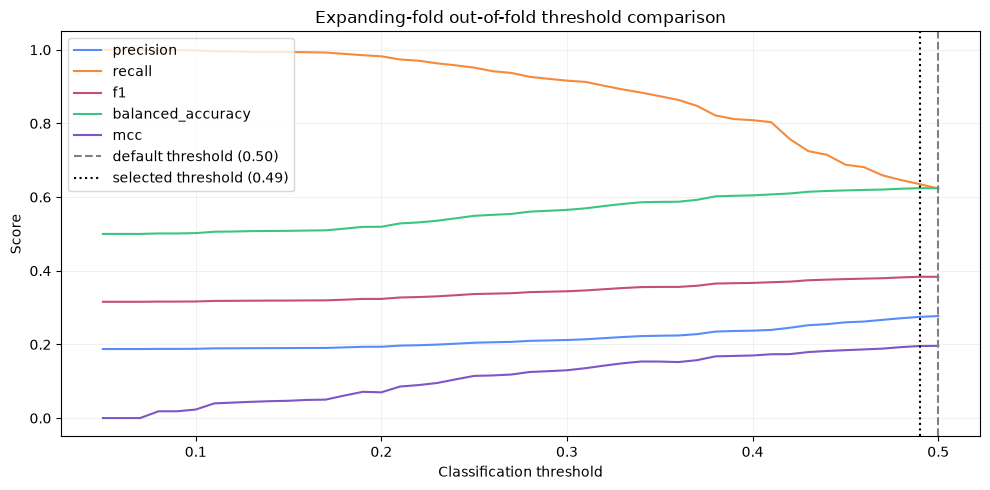

In [12]:
oof_probabilities = np.full(len(y_train), np.nan)

for train_indices, validation_indices in temporal_splits:
    fold_model = clone(best_decision_tree_pipeline)
    fold_model.fit(
        X_train.iloc[train_indices],
        y_train.iloc[train_indices],
    )
    oof_probabilities[validation_indices] = fold_model.predict_proba(
        X_train.iloc[validation_indices]
    )[:, 1]

oof_mask = np.isfinite(oof_probabilities)
assert oof_mask.sum() > 0
assert np.isfinite(oof_probabilities[oof_mask]).all()

candidate_thresholds = np.round(np.arange(0.05, 0.501, 0.01), 2)
threshold_rows = []
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]

for threshold in candidate_thresholds:
    predictions = (oof_p >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": threshold,
            "accuracy": accuracy_score(oof_y, predictions),
            "balanced_accuracy": balanced_accuracy_score(oof_y, predictions),
            "precision": precision_score(oof_y, predictions, zero_division=0),
            "recall": recall_score(oof_y, predictions, zero_division=0),
            "f1": f1_score(oof_y, predictions, zero_division=0),
            "mcc": matthews_corrcoef(oof_y, predictions),
        }
    )

threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"],
    ascending=False,
).iloc[0]
selected_threshold = float(best_threshold_row["threshold"])

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
display(
    threshold_results.sort_values(
        ["f1", "balanced_accuracy", "precision"],
        ascending=False,
    ).head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
for metric in ["precision", "recall", "f1", "balanced_accuracy", "mcc"]:
    ax.plot(threshold_results["threshold"], threshold_results[metric], label=metric)

ax.axvline(0.50, color="gray", linestyle="--", label="default threshold (0.50)")
ax.axvline(
    selected_threshold,
    color="black",
    linestyle=":",
    label=f"selected threshold ({selected_threshold:.2f})",
)
ax.set(
    title="Expanding-fold out-of-fold threshold comparison",
    xlabel="Classification threshold",
    ylabel="Score",
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## Evaluate the 2023 external validation dataset

The grid-selected estimator was refitted automatically on all 2019 training rows. It is now evaluated on 2023 at both the default 0.50 threshold and the threshold selected from 2019 out-of-fold probabilities. The class-prior dummy provides the no-skill reference.

Threshold changes affect label metrics such as precision and recall, but they do not change average precision, ROC AUC, or Brier score.

In [13]:
def evaluate_probabilities(y_true, probabilities, model_name, threshold):
    """Return threshold, ranking, correlation, and calibration metrics."""
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


validation_probabilities = best_decision_tree_pipeline.predict_proba(X_validation)[:, 1]

dummy_model = DummyClassifier(strategy="prior")
dummy_model.fit(X_train, y_train)
dummy_probabilities = dummy_model.predict_proba(X_validation)[:, 1]

evaluation_results = pd.DataFrame(
    [
        evaluate_probabilities(
            y_validation,
            dummy_probabilities,
            "Dummy (2019 class prior)",
            0.50,
        ),
        evaluate_probabilities(
            y_validation,
            validation_probabilities,
            "Decision tree (default threshold)",
            0.50,
        ),
        evaluate_probabilities(
            y_validation,
            validation_probabilities,
            "Decision tree (training-selected threshold)",
            selected_threshold,
        ),
    ]
).set_index("model")

evaluation_results


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Dummy (2019 class prior),0.5000,0.7636,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.2364,0.1829
Decision tree (default threshold),0.5000,0.6690,0.6165,0.3605,0.5169,0.4247,0.2092,0.6603,0.3683,0.2160
Decision tree (training-selected threshold),0.4900,0.6546,0.6210,0.3536,0.5572,0.4326,0.2126,0.6603,0.3683,0.2160


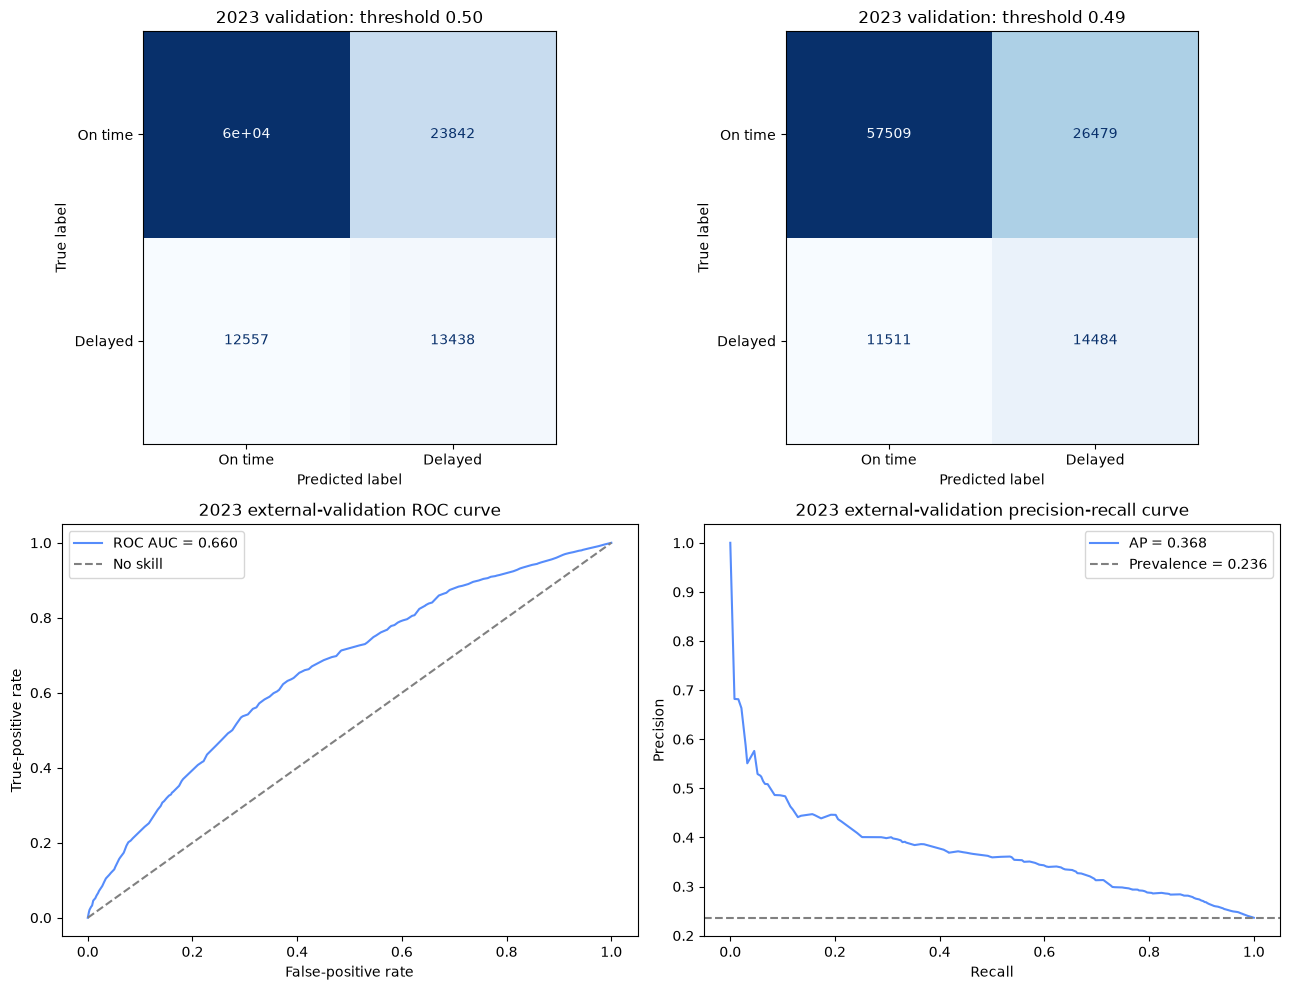

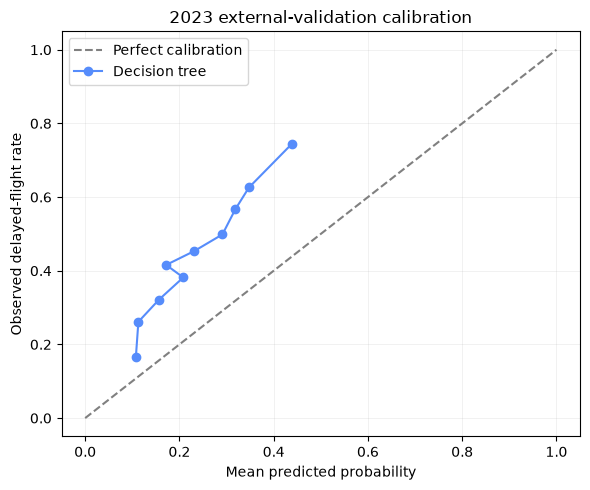

In [14]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)

false_positive_rate, true_positive_rate, _ = roc_curve(y_validation, validation_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_validation, validation_probabilities)
calibration_predicted, calibration_observed = calibration_curve(
    y_validation,
    validation_probabilities,
    n_bins=10,
    strategy="quantile",
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023 validation: threshold 0.50")

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"2023 validation: threshold {selected_threshold:.2f}")

axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ROC AUC = {roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="No skill")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="2023 external-validation ROC curve",
)
axes[1, 0].legend()

axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=f"AP = {average_precision_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 1].axhline(
    y_validation.mean(),
    linestyle="--",
    color="gray",
    label=f"Prevalence = {y_validation.mean():.3f}",
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="2023 external-validation precision-recall curve",
)
axes[1, 1].legend()

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(
    calibration_predicted,
    calibration_observed,
    marker="o",
    label="Decision tree",
)
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delayed-flight rate",
    title="2023 external-validation calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Inspect impurity-based feature importance

The fitted tree reports the total impurity reduction attributed to each encoded predictor. The first table shows encoded columns; the second aggregates one-hot categories back to their source predictor. Impurity importance is descriptive rather than causal and can favor predictors with more possible split points.


In [15]:
def source_feature_from_encoded_name(encoded_name: str) -> str:
    """Map a ColumnTransformer output name back to its source column."""
    transformer_name, transformed_name = encoded_name.split("__", 1)
    if transformer_name == "numeric":
        return transformed_name.removeprefix("missingindicator_")

    for source_name in sorted(categorical_features, key=len, reverse=True):
        if transformed_name == source_name or transformed_name.startswith(f"{source_name}_"):
            return source_name
    return transformed_name


importance_table = (
    pd.DataFrame(
        {
            "encoded_feature": encoded_feature_names,
            "importance": fitted_tree.feature_importances_,
        }
    )
    .assign(
        source_feature=lambda frame: frame["encoded_feature"].map(
            source_feature_from_encoded_name
        )
    )
    .sort_values("importance", ascending=False)
)

source_importance = (
    importance_table.groupby("source_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

display(importance_table.head(20))
source_importance.head(20)


,encoded_feature,importance,source_feature
79,numeric__CRSDepTime,0.4357,CRSDepTime
89,numeric__HourlyDewPointTemperature,0.1117,HourlyDewPointTemperature
92,numeric__HourlyRelativeHumidity,0.1096,HourlyRelativeHumidity
90,numeric__HourlyDryBulbTemperature,0.0671,HourlyDryBulbTemperature
94,numeric__HourlyWindSpeed,0.0446,HourlyWindSpeed
81,numeric__CRSElapsedTime,0.0265,CRSElapsedTime
9,categorical__Month_10,0.0200,Month
22,categorical__Reporting_Airline_B6,0.0196,Reporting_Airline
23,categorical__Reporting_Airline_DL,0.0162,Reporting_Airline
8,categorical__Month_9,0.0139,Month


,source_feature,importance
7,CRSDepTime,0.4357
12,HourlyDewPointTemperature,0.1117
15,HourlyRelativeHumidity,0.1096
18,Month,0.0692
13,HourlyDryBulbTemperature,0.0671
19,Reporting_Airline,0.0474
17,HourlyWindSpeed,0.0446
8,CRSElapsedTime,0.0265
10,Dest,0.0159
9,DayOfWeek,0.0110


## Visualize the first three tree levels

Only the top of the fitted tree is displayed. The full selected tree can contain many leaves and is not useful as a single static figure.


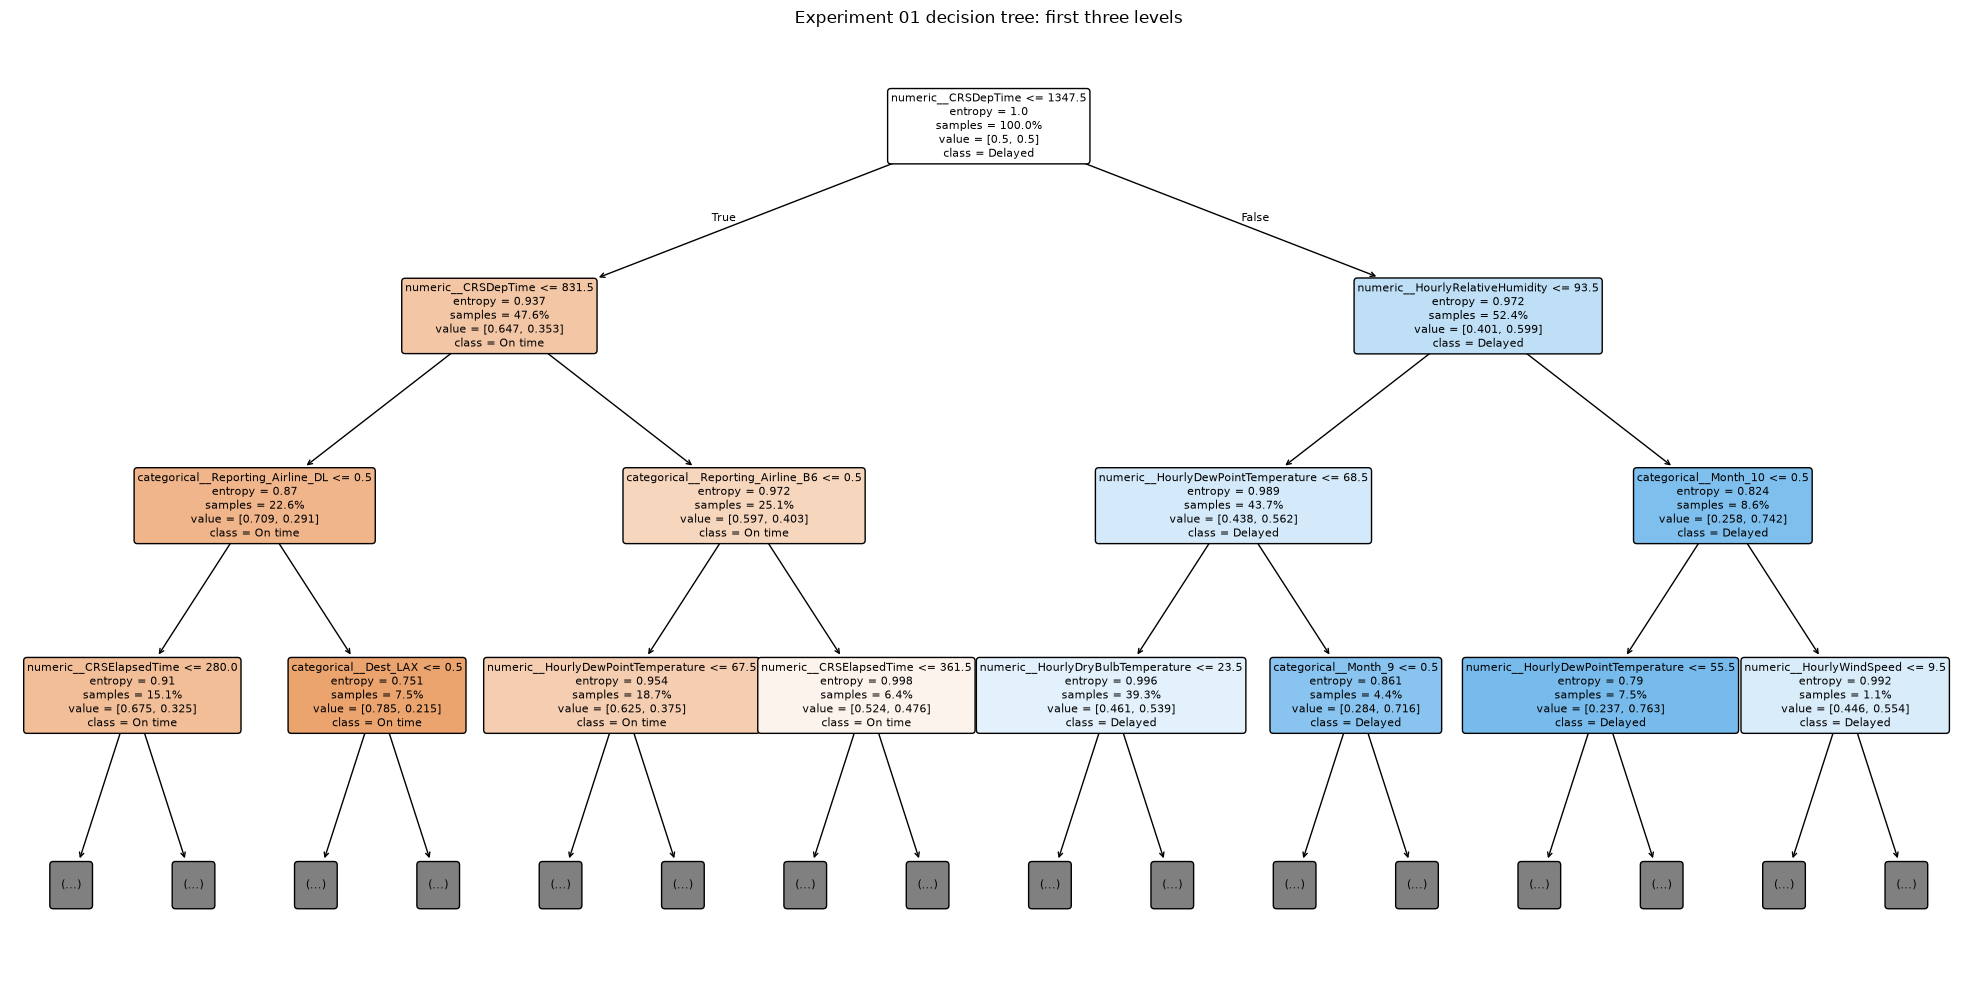

In [16]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    fitted_tree,
    feature_names=encoded_feature_names,
    class_names=["On time", "Delayed"],
    max_depth=3,
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=8,
    ax=ax,
)
ax.set_title("Experiment 01 decision tree: first three levels")
plt.tight_layout()
plt.show()


## Experiment 01 interpretation checklist

Use the displayed results to answer these questions before comparing Experiment 02:

1. Did the best expanding-window configuration beat delayed-flight prevalence by a meaningful margin in average precision?
2. Did its ranking and calibration persist when the all-2019 fit was applied to 2023?
3. What depth and leaf size won, and did class weighting help average precision?
4. How much recall was gained—and how much precision was lost—at the training-selected threshold?
5. Are predicted probabilities reasonably calibrated?
6. Do the dominant source features reflect plausible schedule, traffic, weather, airline, and destination associations?

Treat 2023 as an external development/validation year: its results must not be used to refit or tune this Experiment 01 record. Experiment 02 keeps the same population, folds, validation year, metrics, threshold policy, and tree grid while testing a compact tree-oriented engineered manifest. The 2024 dataset remains locked for final evaluation.
